## 

# Projet d'Analyse de Données — Sleep Efficiency Dataset
### 4MA - INSA Toulouse 2025–2026

---

## Problématique

**Quels sont les facteurs comportementaux, physiologiques et démographiques qui structurent la qualité du sommeil, et peut-on identifier des profils typiques de dormeurs ?**

Nous étudions le jeu de données *Sleep Efficiency* disponible sur Kaggle ([lien](https://www.kaggle.com/datasets/equilibriumm/sleep-efficiency)), qui recense 452 individus décrits par leurs habitudes de sommeil, leur mode de vie et leurs paramètres physiologiques de sommeil.

**Démarche du projet :**
1. Évaluer la qualité du jeu de données (valeurs manquantes, aberrantes, redondances)
2. Réduction linéaire de dimension à l'aide de différentes méthodes d'analyse factorielle (ACP, LDA, FAMD)
3. Identifier des groupes homogènes de dormeurs via un **clustering** 
4. Interpréter les résultats en lien avec la problématique

**Justification du choix du dataset :**  
Ce jeu de données présente un mélange naturel de variables quantitatives continues et de variables qualitatives, ce qui en fait un cas d'usage idéal pour la FAMD. Le sommeil et ses liens avec le mode de vie constituent par ailleurs un sujet qui nous tient à cœur, en tant qu'étudiants attirés par les sciences humaines, ce dataset représente pour nous une occasion concrète de montrer comment les statistiques peuvent éclairer des comportements du quotidien.

### 0. Importation des bibliothèques 

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats


### 1. Chargement des données

#### 1.1 Description des variables :

Pour chaque individu, on observe les **15 variables** suivantes :

* `ID` : Identifiant unique de l'individu
* `Age` : Âge en années
* `Gender` : Genre de l'individu (Male / Female)
* `Bedtime` : Heure de coucher (format datetime)
* `Wakeup time` : Heure de réveil (format datetime)
* `Sleep duration` : Durée totale du sommeil en heures
* `Sleep efficiency` : Proportion du temps au lit effectivement passé à dormir (entre 0 et 1)
* `REM sleep percentage` : Part du sommeil passée en phase REM (Rapid Eye Movement) (%), correspondant à une phase de sommeil où l’activité cérébrale est élevée et où surviennent la majorité des rêves 
* `Deep sleep percentage` : Part du sommeil passée en sommeil profond (%)
* `Light sleep percentage` : Part du sommeil passée en sommeil léger (%)
* `Awakenings` : Nombre de réveils nocturnes
* `Caffeine consumption` : Quantité de caféine consommée dans les 24h précédant le coucher (mg)
* `Alcohol consumption` : Quantité d'alcool consommée dans les 24h précédant le coucher (en onces, oz)
* `Smoking status` : Statut tabagique de l'individu (Yes / No)
* `Exercise frequency` : Fréquence d'activité physique hebdomadaire (jours/semaine)


In [7]:
df = pd.read_csv('Sleep_Efficiency.csv')
display( 
    df.head().style.background_gradient(cmap='BuPu')
)
print("Dimensions:", df.shape)
df.info()
df.describe(include='all')


,ID,Age,Gender,Bedtime,Wakeup time,Sleep duration,Sleep efficiency,REM sleep percentage,Deep sleep percentage,Light sleep percentage,Awakenings,Caffeine consumption,Alcohol consumption,Smoking status,Exercise frequency
0,1,65,Female,2021-03-06 01:00:00,2021-03-06 07:00:00,6.000000,0.880000,18,70,12,0.000000,0.000000,0.000000,Yes,3.000000
1,2,69,Male,2021-12-05 02:00:00,2021-12-05 09:00:00,7.000000,0.660000,19,28,53,3.000000,0.000000,3.000000,Yes,3.000000
2,3,40,Female,2021-05-25 21:30:00,2021-05-25 05:30:00,8.000000,0.890000,20,70,10,1.000000,0.000000,0.000000,No,3.000000
3,4,40,Female,2021-11-03 02:30:00,2021-11-03 08:30:00,6.000000,0.510000,23,25,52,3.000000,50.000000,5.000000,Yes,1.000000
4,5,57,Male,2021-03-13 01:00:00,2021-03-13 09:00:00,8.000000,0.760000,27,55,18,3.000000,0.000000,3.000000,No,3.000000


Dimensions: (452, 15)
<class 'pandas.DataFrame'>
RangeIndex: 452 entries, 0 to 451
Data columns (total 15 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   ID                      452 non-null    int64  
 1   Age                     452 non-null    int64  
 2   Gender                  452 non-null    str    
 3   Bedtime                 452 non-null    str    
 4   Wakeup time             452 non-null    str    
 5   Sleep duration          452 non-null    float64
 6   Sleep efficiency        452 non-null    float64
 7   REM sleep percentage    452 non-null    int64  
 8   Deep sleep percentage   452 non-null    int64  
 9   Light sleep percentage  452 non-null    int64  
 10  Awakenings              432 non-null    float64
 11  Caffeine consumption    427 non-null    float64
 12  Alcohol consumption     438 non-null    float64
 13  Smoking status          452 non-null    str    
 14  Exercise frequency      446 non

,ID,Age,Gender,Bedtime,Wakeup time,Sleep duration,Sleep efficiency,REM sleep percentage,Deep sleep percentage,Light sleep percentage,Awakenings,Caffeine consumption,Alcohol consumption,Smoking status,Exercise frequency
count,452.000000,452.000000,452,452,452,452.000000,452.000000,452.000000,452.000000,452.000000,432.000000,427.000000,438.000000,452,446.000000
unique,NaN,NaN,2,424,434,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,NaN
top,NaN,NaN,Male,2021-03-11 01:00:00,2021-12-05 09:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,No,NaN
freq,NaN,NaN,228,3,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,298,NaN
mean,226.500000,40.285398,NaN,NaN,NaN,7.465708,0.788916,22.615044,52.823009,24.561947,1.641204,23.653396,1.173516,NaN,1.791480
std,130.625419,13.172250,NaN,NaN,NaN,0.866625,0.135237,3.525963,15.654235,15.313665,1.356762,30.202785,1.621377,NaN,1.428134
min,1.000000,9.000000,NaN,NaN,NaN,5.000000,0.500000,15.000000,18.000000,7.000000,0.000000,0.000000,0.000000,NaN,0.000000
25%,113.750000,29.000000,NaN,NaN,NaN,7.000000,0.697500,20.000000,48.250000,15.000000,1.000000,0.000000,0.000000,NaN,0.000000
50%,226.500000,40.000000,NaN,NaN,NaN,7.500000,0.820000,22.000000,58.000000,18.000000,1.000000,25.000000,0.000000,NaN,2.000000
75%,339.250000,52.000000,NaN,NaN,NaN,8.000000,0.900000,25.000000,63.000000,32.500000,3.000000,50.000000,2.000000,NaN,3.000000



Le jeu de données contient **452 observations** et **15 variables**, dont :

- **5 variables quantitatives(entières)** : ID, Age, REM, Deep et Light sleep percentage  
- **6 variables quantitatives(continues)** : Sleep duration, Sleep efficiency, Awakenings, Caffeine, Alcohol, Exercise frequency  
- **4 variables qualitatives**: Gender, Bedtime, Wakeup time, Smoking status  




#### 1.2 Nettoyage et préparation du dataset

Cette section a pour objectif de :
- Charger et inspecter le jeu de données
- Vérifier la qualité des données
- Identifier et traiter les valeurs manquantes
- Détecter et traiter les outliers


In [8]:
n_duplicated = df.duplicated().sum()
print(f"Number of duplicated rows: {n_duplicated}\n")

df_aux = pd.DataFrame({
    'n_unique':df.nunique(),
    'n_missing':df.isna().sum(),
    'missing_ratio':df.isna().mean(),
    'dtype':df.dtypes.values
})

display(
    df_aux.style.background_gradient(cmap='BuPu')
        .format({"missing_ratio": "{:.2%}"})
)

Number of duplicated rows: 0



,n_unique,n_missing,missing_ratio,dtype
ID,452,0,0.00%,int64
Age,61,0,0.00%,int64
Gender,2,0,0.00%,str
Bedtime,424,0,0.00%,str
Wakeup time,434,0,0.00%,str
Sleep duration,9,0,0.00%,float64
Sleep efficiency,50,0,0.00%,float64
REM sleep percentage,13,0,0.00%,int64
Deep sleep percentage,29,0,0.00%,int64
Light sleep percentage,29,0,0.00%,int64


Le tableau révèle 4 variables avec des valeurs manquantes, toutes inférieures à 6%, ces taux étant faibles, nous avons choisi de remplir ces valeurs manquantes plutôt que de supprimer les lignes concernées, afin de ne pas perdre d'information.

On note également que `Bedtime` et `Wakeup time` affichent une très haute cardinalité (424 et 434 valeurs uniques sur 452), ce qui confirme leur caractère quasi-individuel.

Aucun doublon n'a été détecté dans le jeu de données ce qui est confirmé par la variable `ID` qui présente bien 452 valeurs uniques.

##### 1.2.1 Suppression des colonnes redondantes

- La variable `ID` n'apportant aucune information est supprimée.
- Les variables `Bedtime` et `Wakeup time`, représentées sous forme de chaînes de caractères, sont redondantes avec `Sleep duration` qui capture déjà l'information essentielle. On extrait néanmoins une variable numérique `bedtime_hour` représentant l'heure du coucher, puis les deux colonnes originales sont supprimées.
- Concernant `bedtime_hour`, on récupère l'heure de la variable `Bedtime` uniquement, sans conserver la date complète: elle ne constitue pas une variable quantitative pertinente et ne peut pas non plus être traitée efficacement comme variable qualitative en raison de sa très forte cardinalité

In [9]:
#Création de la variable bedtime_hour
df['Bedtime'] = pd.to_datetime(df['Bedtime'])
df['bedtime_hour'] =df['Bedtime'].dt.hour + df['Bedtime'].dt.minute / 60



In [10]:
# Vérification des horaires de coucher (avant transformation)

# Entre minuit (0h) et midi (12h)
minuit_midi = ((df['bedtime_hour'] >= 0) & (df['bedtime_hour'] < 12)).sum()

# Entre midi (12h) et 20h
midi_20h = ((df['bedtime_hour'] >= 12) & (df['bedtime_hour'] < 20)).sum()

# Entre 20h et 23h59
vingt_24h = ((df['bedtime_hour'] >= 20) & (df['bedtime_hour'] < 24)).sum()

print("0h - 12h :", minuit_midi)
print("12h - 20h :", midi_20h)
print("20h - 24h :", vingt_24h)


0h - 12h : 241
12h - 20h : 0
20h - 24h : 211


L’analyse des horaires de coucher montre que les individus se couchent majoritairement entre 20h et minuit ou après minuit, tandis qu’aucune observation ne correspond à des heures comprises entre midi et 20h ; cela confirme le choix du seuil de 20h.

In [11]:
# Normalisation : les heures entre 20h et 23h59 deviennent négatives (avant minuit) afin de représenter la continuité temporelle (20h=−4, 23h=−1, 0h=0, 4h=4)
df['bedtime_hour'] = df['bedtime_hour'].apply(lambda h: h - 24 if h >= 20 else h)

cols_to_drop = ['ID', 'Bedtime', 'Wakeup time']
df.drop(columns=cols_to_drop, inplace=True)

Les heures de coucher comprises entre 20h et 23h59 ont été transformées en valeurs négatives (h − 24) afin de corriger la discontinuité autour de minuit, ce qui permet de représenter de manière plus cohérente la continuité des horaires de sommeil.   

##### 1.2.2 Gestion des valeurs manquantes

Les 4 variables concernées (`Awakenings`, `Caffeine consumption`, `Alcohol consumption`, `Exercise frequency`) présentent toutes un taux inférieur à 6% des valeurs manquantes. 


In [12]:
cols_to_impute = ['Awakenings', 'Caffeine consumption', 'Alcohol consumption', 'Exercise frequency']

for col in cols_to_impute:
    med_val = df[col].median()
    df[col] = df[col].fillna(med_val)


print("Vérification des valeurs manquantes :")
print(df.isnull().sum())

Vérification des valeurs manquantes :
Age                       0
Gender                    0
Sleep duration            0
Sleep efficiency          0
REM sleep percentage      0
Deep sleep percentage     0
Light sleep percentage    0
Awakenings                0
Caffeine consumption      0
Alcohol consumption       0
Smoking status            0
Exercise frequency        0
bedtime_hour              0
dtype: int64


##### 1.2.3 Détection des outliers

Nous utilisons des boxplots pour visualiser la distribution 
de chaque variable quantitative et repérer les valeurs aberrantes.

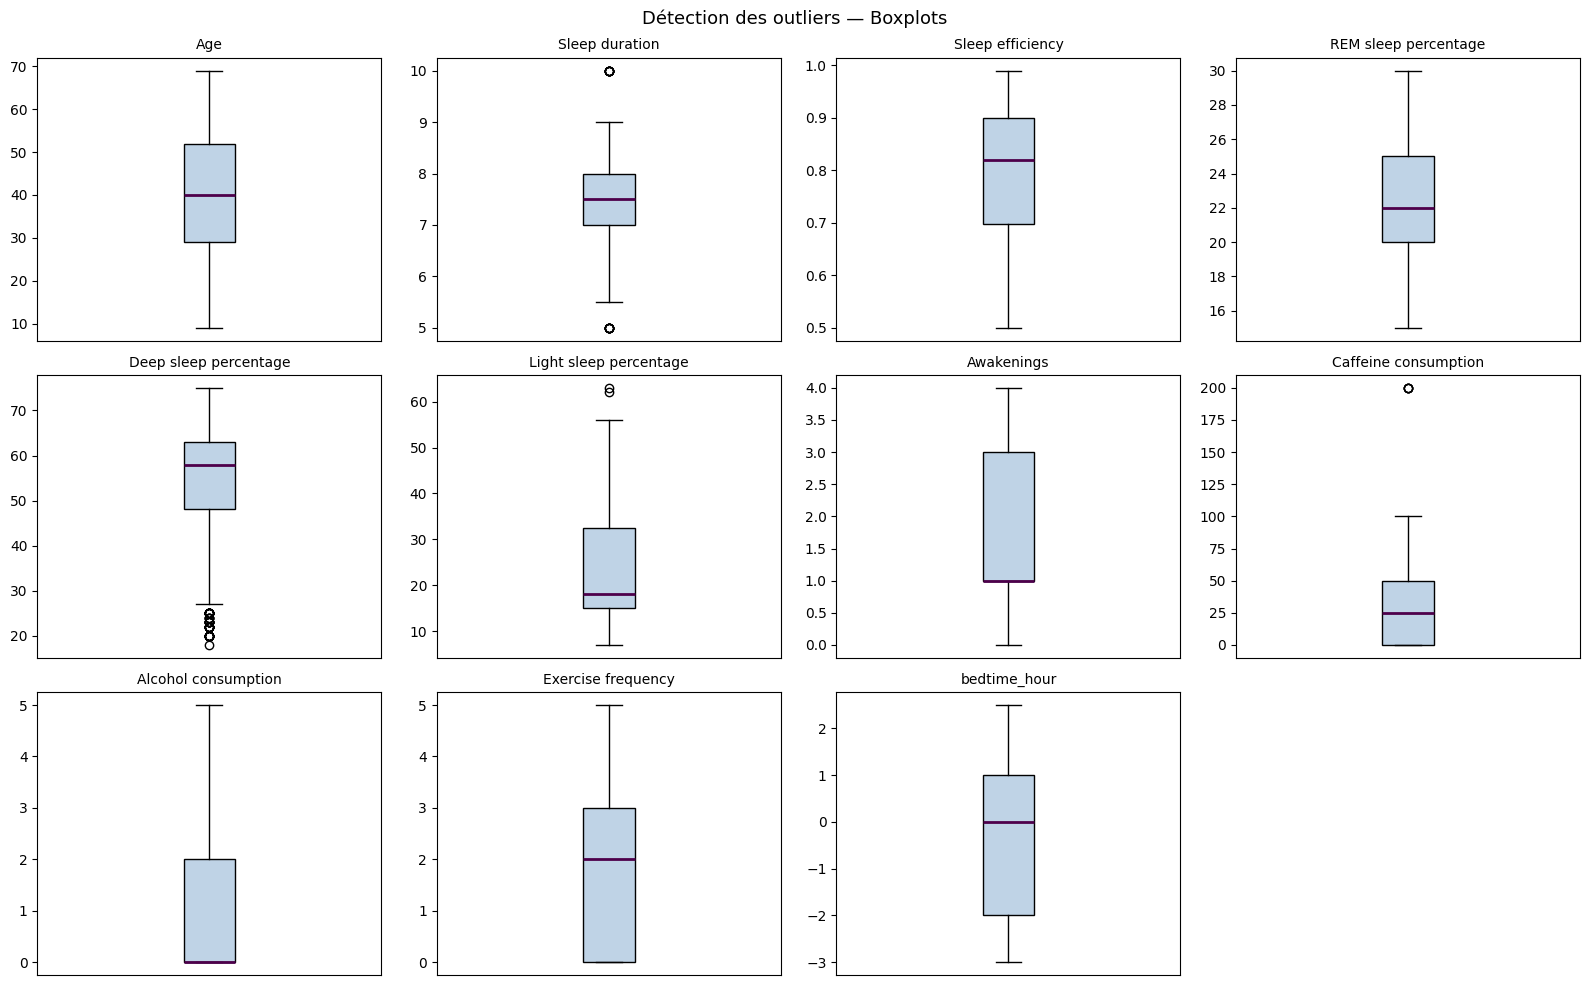

In [13]:
quant_cols = ['Age', 'Sleep duration', 'Sleep efficiency', 
              'REM sleep percentage', 'Deep sleep percentage',
              'Light sleep percentage', 'Awakenings', 
              'Caffeine consumption', 'Alcohol consumption', 
              'Exercise frequency', 'bedtime_hour']

fig, axes = plt.subplots(3, 4, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(quant_cols):
    axes[i].boxplot(df[col], patch_artist=True,
                    boxprops=dict(facecolor='#BFD3E6'),
                    medianprops=dict(color='#4D004B', linewidth=2))
    axes[i].set_title(col, fontsize=10)
    axes[i].set_xticks([])

# On cache le dernier subplot vide
axes[-1].set_visible(False)

plt.suptitle('Détection des outliers — Boxplots', fontsize=13)
plt.tight_layout()
plt.show()

Les boxplots montrent que les données sont globalement propres, avec très peu de valeurs extrêmes. La seule valeur notable est `Caffeine consumption` avec un individu à 200mg, une valeur élevée mais tout à fait réelle. Nous choisissons de la conserver telle quelle car elle reflète un comportement existant dans la population.

### 2.Analyse bidimensionnelle

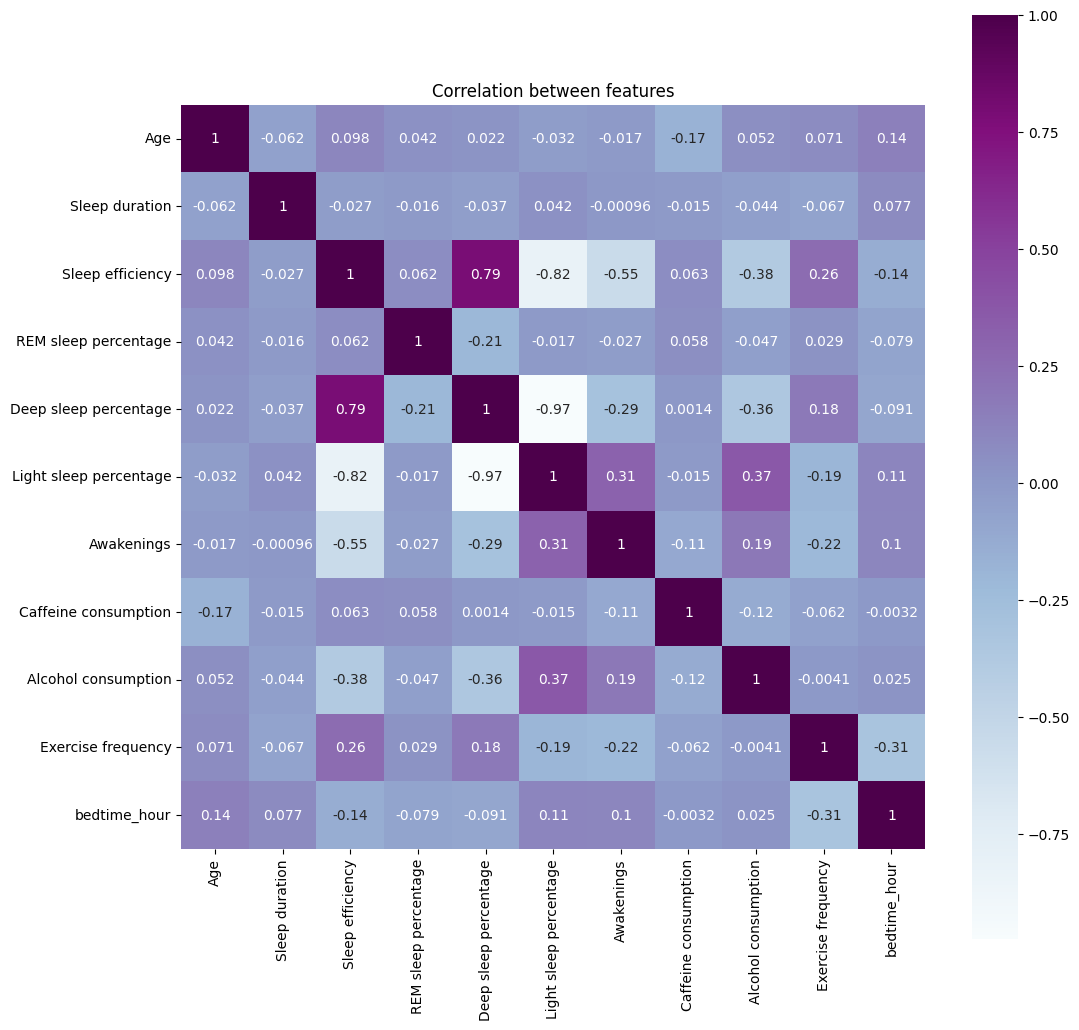

In [14]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(12, 12))
sns.heatmap(corr, annot=True, square=True, cmap='BuPu')
plt.title('Correlation between features')
plt.show()

La matrice de corrélation met en évidence plusieurs relations :

**Corrélations fortes :**
- `Deep sleep percentage` et `Light sleep percentage` sont très fortement corrélées négativement (-0.97), ce qui est logique car ces deux variables sont complémentaires, plus on passe de temps en sommeil profond, moins on passe de temps en sommeil léger. 
- `Sleep efficiency` et `Deep sleep percentage` sont fortement corrélées positivement (0.79), un sommeil plus profond est associé à une meilleure efficacité du sommeil.
- `Sleep efficiency` et `Light sleep percentage` sont fortement corrélées négativement (-0.82), plus on passe de temps en sommeil léger, moins le sommeil est efficace.

**Corrélations modérées :**
- `Awakenings` et `Sleep efficiency` (-0.55), se réveiller souvent
la nuit dégrade la qualité du sommeil.
- `Alcohol consumption` et `Sleep efficiency` (-0.38), la consommation
d'alcool est associée à une moins bonne qualité de sommeil.
- `Exercise frequency` et `bedtime_hour` (-0.31), les personnes qui
font plus de sport ont tendance à se coucher plus tôt.

**Le reste des variables** présente des corrélations faibles, ce qui
suggère qu'elles apportent des informations indépendantes et complémentaires.

### 3. Analyse en composantes pricipales (ACP)


Nous manipulons ici des individus décrits par 11 dimensions (nos variables quantitatives), ce qui s'avère trop complexe à visualiser directement. Pour mieux appréhender les relations entre ces individus et leurs habitudes de sommeil, nous pouvons utiliser l'ACP pour les projeter dans un espace de dimension réduite, beaucoup plus facile à interpréter. 
Les variables étant exprimées dans des unités différentes, sont centrées et réduites afin qu'aucune variable ne domine les autres du fait de son échelle.

In [19]:
import prince

# On récupère les variables quantitatives
X = df[quant_cols]

# PCA avec prince
pca = prince.PCA(
    n_components=8,
    n_iter=10,
    rescale_with_mean=True,
    rescale_with_std=True,
    copy=True,
    check_input=True,
    engine='sklearn',
    random_state=42
)

# Fit du modèle
pca = pca.fit(X)

# Projection des données
projected = pca.transform(X)

print("--- PCA ---")
print(f"Initial dimension: {X.shape}")
print(f"Dimension after projection: {projected.shape}\n")

print("--- Explained variance ---")
summary = pca.eigenvalues_summary

for i in range(len(summary)):
    # On récupère la valeur brute (qui est déjà un texte comme "29.70%")
    percentage = summary.iloc[i, 1] 
    print(f"Component {i+1}: {percentage} of the total variance")

--- PCA ---
Initial dimension: (452, 11)
Dimension after projection: (452, 8)

--- Explained variance ---
Component 1: 29.70% of the total variance
Component 2: 12.10% of the total variance
Component 3: 11.47% of the total variance
Component 4: 9.87% of the total variance
Component 5: 9.00% of the total variance
Component 6: 8.11% of the total variance
Component 7: 6.48% of the total variance
Component 8: 6.36% of the total variance


Ce résultat nous montre que l'algorithme a bien conservé nos 452 individus, mais a condensé nos variables de départ en 8 nouvelles composantes classées par ordre d'importance. Le premier axe fait le plus gros du travail en captant près de 30 % de l'information totale à lui tout seul, puis l'apport des axes suivants baisse progressivement. On remarque d'ailleurs qu'à partir de la quatrième composante, les axes restants n'apportent plus que de faibles pourcentages (moins de 10 % d'information chacun).

Bien que nous ayons les pourcentages exacts de variance expliquée, il est toujours préférable de les représenter graphiquement. Le graphique de l'éboulis nous permet de repérer visuellement la chute d'information entre les différents axes.

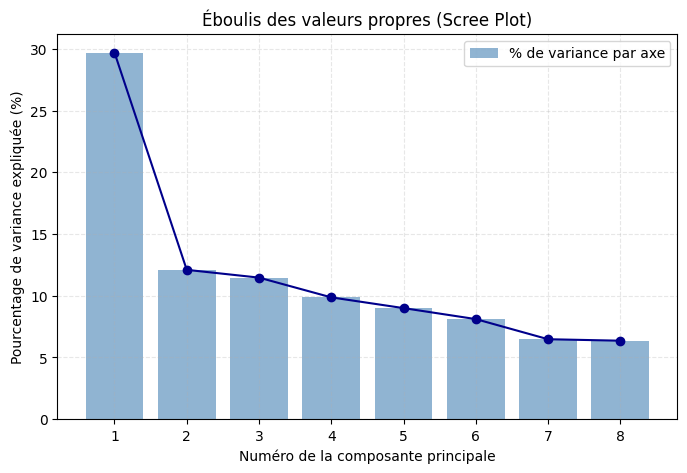

In [24]:


# On extrait les pourcentages de variance (colonne 1) et on enlève le symbole '%' pour pouvoir les tracer
# Note : summary.iloc[:, 1] contient les textes "29.70%", etc.
variances = summary.iloc[:, 1].str.replace('%', '').astype(float)

plt.figure(figsize=(8, 5))

# Création du graphique en barres + ligne
plt.bar(range(1, len(variances) + 1), variances, alpha=0.6, color='steelblue', label="% de variance par axe")
plt.plot(range(1, len(variances) + 1), variances, marker='o', color='darkblue')

plt.title("Éboulis des valeurs propres (Scree Plot)")
plt.xlabel("Numéro de la composante principale")
plt.ylabel("Pourcentage de variance expliquée (%)")

# Pour avoir de beaux numéros entiers sur l'axe X (1, 2, 3... 8)
plt.xticks(range(1, len(variances) + 1))
plt.grid(True, linestyle='--', alpha=0.3)
plt.legend()

plt.show()

L'observation de cet éboulis des valeurs propres confirme visuellement la chute d'information après le premier axe. Il nous faudrait conserver au moins 6 composantes pour atteindre le seuil recommandé des 80 % de variance expliquée. Cependant, nous faisons le choix de n'en retenir que 3. En effet, ces trois premiers axes capturent plus de 53 % de l'information totale, ce qui constitue un résumé solide. Surtout, ce choix est dicté par une nécessité de visualisation : se limiter à 3 dimensions nous permet de projeter et d'interpréter facilement le profil de nos individus sur des graphiques lisibles. Si nous avions gardé 6 composantes, toute représentation visuelle claire aurait été impossible.

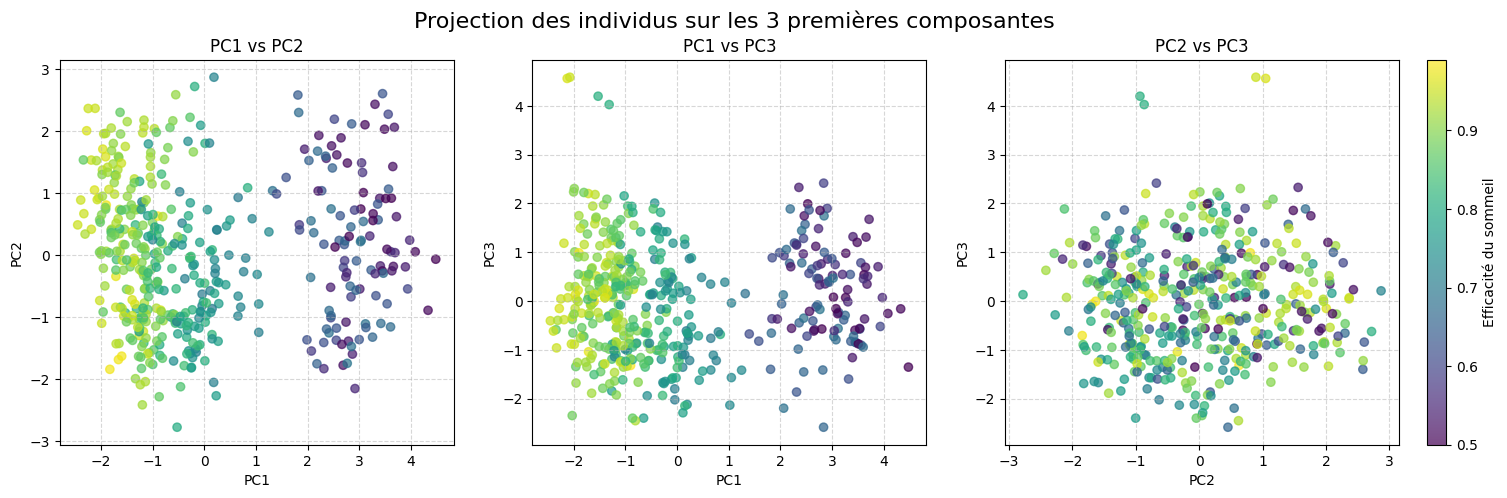

In [28]:


# On crée une grande figure avec 3 graphiques (1 ligne, 3 colonnes)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Projection des individus sur les 3 premières composantes", fontsize=16)

# PC1 vs PC2
sc1 = axes[0].scatter(projected.iloc[:, 0], projected.iloc[:, 1], c=df['Sleep efficiency'], cmap='viridis', alpha=0.7)
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')
axes[0].set_title('PC1 vs PC2')
axes[0].grid(True, linestyle='--', alpha=0.5)

# PC1 vs PC3
sc2 = axes[1].scatter(projected.iloc[:, 0], projected.iloc[:, 2], c=df['Sleep efficiency'], cmap='viridis', alpha=0.7)
axes[1].set_xlabel('PC1')
axes[1].set_ylabel('PC3')
axes[1].set_title('PC1 vs PC3')
axes[1].grid(True, linestyle='--', alpha=0.5)

# PC2 vs PC3
sc3 = axes[2].scatter(projected.iloc[:, 1], projected.iloc[:, 2], c=df['Sleep efficiency'], cmap='viridis', alpha=0.7)
axes[2].set_xlabel('PC2')
axes[2].set_ylabel('PC3')
axes[2].set_title('PC2 vs PC3')
axes[2].grid(True, linestyle='--', alpha=0.5)

# On ajoute une seule barre de couleur commune tout à droite
cbar = fig.colorbar(sc1, ax=axes, orientation='vertical', fraction=0.02, pad=0.02)
cbar.set_label("Efficacité du sommeil")

plt.show()

En observant les deux premiers graphiques, on constate que la séparation parfaite entre les bons et les mauvais dormeurs se fait de manière stricte le long de l'axe PC1. À l'inverse, le troisième graphique (PC2 vs PC3) affiche un nuage de points où les couleurs sont totalement mélangées. La conclusion majeure à en tirer est que notre première composante a réussi à capter la quasi-totalité des facteurs qui influencent l'efficacité du sommeil. Les composantes 2 et 3 représentent d'autres profils comportementaux de nos patients (comme peut-être des habitudes de consommation ou l'âge) qui structurent notre jeu de données mais qui n'ont pas d'impact direct ou systématique sur la qualité globale de leur sommeil.

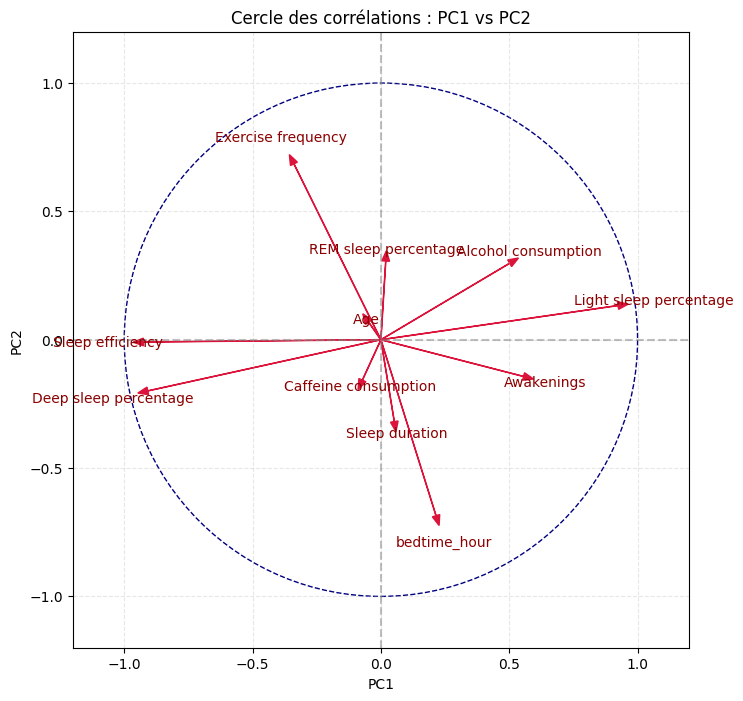

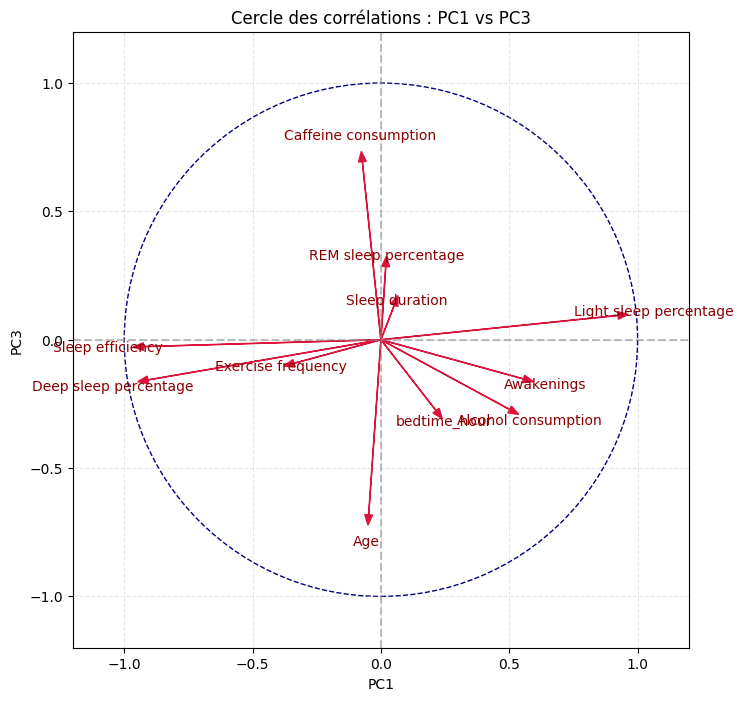

In [31]:
import matplotlib.pyplot as plt
import numpy as np

# 1. LA CORRECTION EST ICI : on retire le (X)
correlations = pca.column_correlations

def plot_correlation_circle(comp_x, comp_y):
    fig, ax = plt.subplots(figsize=(8, 8))
    
    # Dessin du cercle unité
    circle = plt.Circle((0, 0), 1, color='navy', fill=False, linestyle='--')
    ax.add_artist(circle)
    
    # Axes
    plt.axhline(0, color='gray', linestyle='--', alpha=0.5)
    plt.axvline(0, color='gray', linestyle='--', alpha=0.5)
    
    # Variables
    for i, var in enumerate(correlations.index):
        x = correlations.iloc[i, comp_x]
        y = correlations.iloc[i, comp_y]
        
        # Dessin de la flèche
        ax.arrow(0, 0, x, y, head_width=0.03, head_length=0.04, fc='crimson', ec='crimson')
        # Ajout du texte
        plt.text(x*1.15, y*1.15, var, color='darkred', ha='center', va='center', fontsize=10)

    plt.xlim(-1.2, 1.2)
    plt.ylim(-1.2, 1.2)
    ax.set_aspect('equal')
    plt.title(f"Cercle des corrélations : PC{comp_x+1} vs PC{comp_y+1}")
    plt.xlabel(f"PC{comp_x+1}")
    plt.ylabel(f"PC{comp_y+1}")
    plt.grid(True, linestyle='--', alpha=0.3)
    plt.show()

# Affichage des deux vues principales
plot_correlation_circle(0, 1) # PC1 vs PC2
plot_correlation_circle(0, 2) # PC1 vs PC3

L'axe PC1 prouve que ce qui détruit l'efficacité du sommeil dans notre jeu de données, c'est la fragmentation (les réveils) causée par l'alcool, qui maintient l'individu dans un stade de sommeil léger. C'est exactement pour cela que, sur nos précédents nuages de points, les "bons dormeurs" étaient tous massés à gauche et les "mauvais" à droite !

L'axe PC2 sépare les profils plutôt sportifs des profils "couche-tard". Ces flèches sont presque verticales : elles sont donc indépendantes de l'axe PC1. Cela signifie que dans nos données, être sportif ou se coucher tard définit qui est le patient, mais ne garantit pas à 100% s'il dormira bien ou mal (c'est l'alcool et les réveils qui dictent cela sur PC1). 

D'après l'axe 3, les patients plus âgés ont tendance à consommer moins de caféine (ou inversement, les jeunes en consomment beaucoup). Encore une fois, comme ces variables sont sur un axe différent de PC1, cela montre que l'âge ou le café modèlent le profil du patient, mais sont moins déterminants pour l'efficacité globale du sommeil.

### Clustering K-means 

##### Prépartion et choix de K :

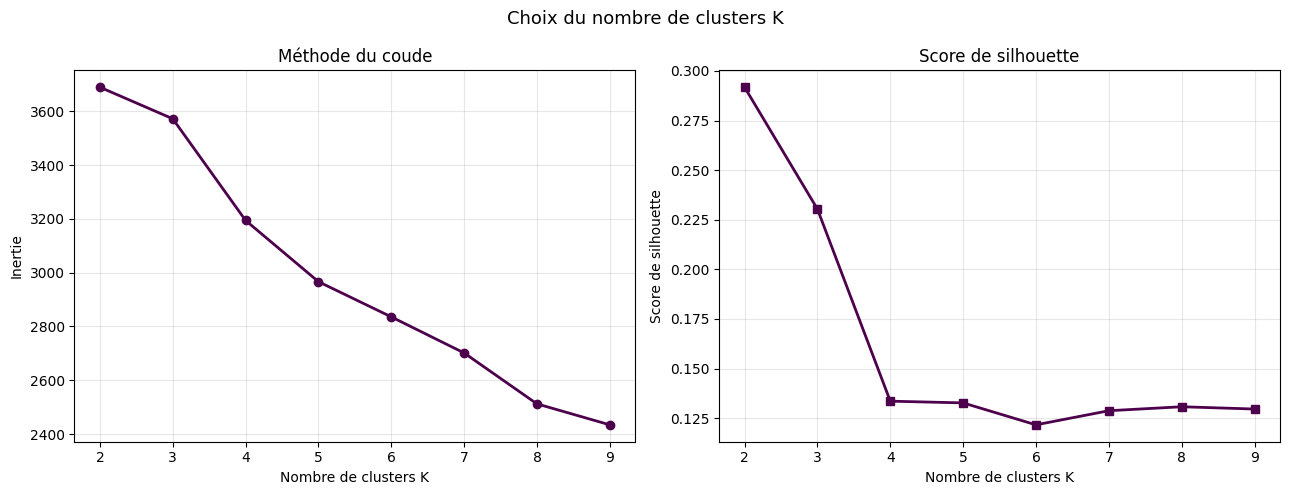

Meilleur K : 2


In [17]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.decomposition import PCA

# Espace de clustering = coordonnées ACP
pca_kmeans = PCA()
X_pca = pca_kmeans.fit_transform(X_scaled)

# Choix de K — méthode du coude + silhouette
inertias, silhouettes = [], []
k_range = range(2, 10)

for k in k_range:
    km = KMeans(n_clusters=k, init='k-means++', 
                n_init='auto', max_iter=100, random_state=42)
    labels = km.fit_predict(X_pca)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_pca, labels))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

ax1.plot(list(k_range), inertias, 'o-', color='#4D004B', linewidth=2)
ax1.set_xlabel('Nombre de clusters K')
ax1.set_ylabel('Inertie')
ax1.set_title('Méthode du coude')
ax1.set_xticks(list(k_range))
ax1.grid(True, alpha=0.3)

ax2.plot(list(k_range), silhouettes, 's-', color='#4D004B', linewidth=2)
ax2.set_xlabel('Nombre de clusters K')
ax2.set_ylabel('Score de silhouette')
ax2.set_title('Score de silhouette')
ax2.set_xticks(list(k_range))
ax2.grid(True, alpha=0.3)

plt.suptitle('Choix du nombre de clusters K', fontsize=13)
plt.tight_layout()
plt.show()


print(f"Meilleur K : {list(k_range)[silhouettes.index(max(silhouettes))]}")

Les deux graphiques pointent vers **K = 2**, le score de silhouette est maximal et l'inertie commence à peine à décroître après ce point. On retient donc **K = 2**.

#### Application du Clustering avec le K choisi

In [18]:
K_FINAL = 2

# Application du K-means final
kmeans_final = KMeans(n_clusters=K_FINAL, init='k-means++',
                      n_init=50, max_iter=300, random_state=42)
clusters = kmeans_final.fit_predict(X_pca)

sil = silhouette_score(X_pca, clusters)
print(f"Score de silhouette final : {sil:.3f}")
print(f"\nTaille des clusters :")
unique, counts = np.unique(clusters, return_counts=True)
for k, n in zip(unique, counts):
    print(f"  Cluster {k+1} : {n} individus")

Score de silhouette final : 0.292

Taille des clusters :
  Cluster 1 : 113 individus
  Cluster 2 : 339 individus


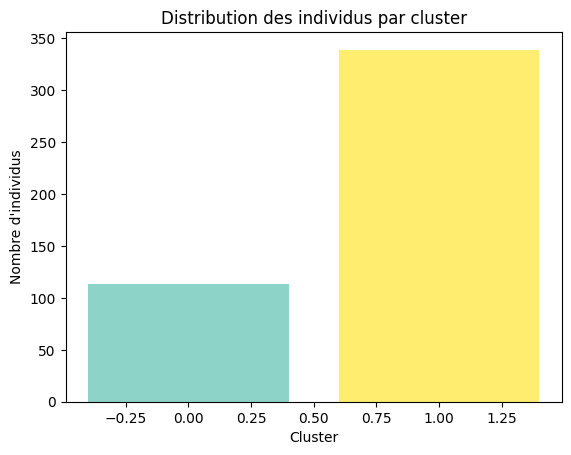

In [19]:
cmp = plt.get_cmap('Set3',K_FINAL)
plt.bar(*np.unique(clusters,return_counts=True), color=cmp.colors)
plt.ylabel("Nombre d'individus")
plt.xlabel("Cluster")
plt.title("Distribution des individus par cluster")
plt.show()

Le K-means identifie deux clusters de tailles très inégales : **113 individus** dans le premier et **339 dans le second**. 
Le score de silhouette de **0.292** indique une séparation modérée les clusters existent mais ne sont pas parfaitement distincts, ce qui est cohérent avec la nature continue des données de sommeil.

#### Visualisation sur le plan de l'ACP

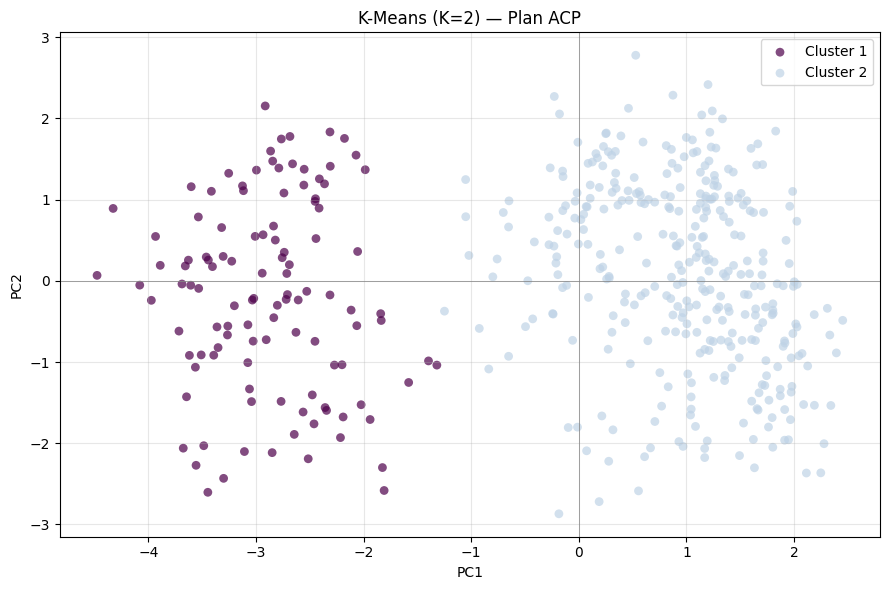

In [20]:
# Visualisation dans le plan ACP
pca_2d = PCA(n_components=2)
X_2d = pca_2d.fit_transform(X_scaled)
centroids_2d = pca_2d.transform(kmeans_final.cluster_centers_)

palette = ['#4D004B', '#BFD3E6']
fig, ax = plt.subplots(figsize=(9, 6))

for k in range(K_FINAL):
    mask = clusters == k
    ax.scatter(X_2d[mask, 0], X_2d[mask, 1],
               color=palette[k], label=f'Cluster {k+1}',
               alpha=0.7, s=40, edgecolors='none')


ax.axhline(0, color='grey', linewidth=0.5)
ax.axvline(0, color='grey', linewidth=0.5)
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_title(f'K-Means (K={K_FINAL}) — Plan ACP')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

La séparation entre les deux clusters est nette sur l'axe PC1 :
le **Cluster 1** (violet, 113 individus) se situe entièrement à gauche, correspondant aux individus avec une **faible efficacité de sommeil**. 
Le **Cluster 2** (bleu, 339 individus) occupe la partie droite, regroupant les **bons dormeurs**. 

Ce résultat est cohérent avec l'interprétation de PC1 comme axe 
de qualité du sommeil établie précédemment.

In [21]:
# Ajouter les clusters au dataframe
df_ref = df.dropna(subset=quant_cols).reset_index(drop=True)
df_ref['cluster'] = clusters + 1  # pour avoir Cluster 1 et 2

# Moyennes par cluster
profile = df_ref.groupby('cluster')[quant_cols].mean().round(2)
display(profile.T.style.background_gradient(cmap='BuPu'))

cluster,1,2
Age,38.710000,40.810000
Sleep duration,7.520000,7.450000
Sleep efficiency,0.590000,0.850000
REM sleep percentage,22.300000,22.720000
Deep sleep percentage,27.420000,61.290000
Light sleep percentage,50.280000,15.990000
Awakenings,2.350000,1.370000
Caffeine consumption,22.350000,24.190000
Alcohol consumption,2.140000,0.800000
Exercise frequency,1.290000,1.960000


Le tableau des moyennes par cluster révèle deux profils bien distincts :

**Cluster 1 : Mauvais dormeurs (113 individus) :**
- `Sleep efficiency` très faible (0.59 vs 0.85)
- Beaucoup de sommeil léger (50% vs 16%) et peu de sommeil profond (27% vs 61%)
- Plus de réveils nocturnes (2.35 vs 1.37)
- Plus de consommation d'alcool (2.14 vs 0.80)
- Moins d'exercice (1.29 vs 1.96)

**Cluster 2 : Bons dormeurs (339 individus) :**
- `Sleep efficiency` élevée (0.85)
- Sommeil majoritairement profond (61%)
- Moins de réveils, moins d'alcool, plus d'exercice

Les variables `Age`, `Sleep duration`, `REM sleep percentage` et 
`Caffeine consumption` sont similaires entre les deux groupes — 
elles ne semblent pas être des facteurs discriminants majeurs.

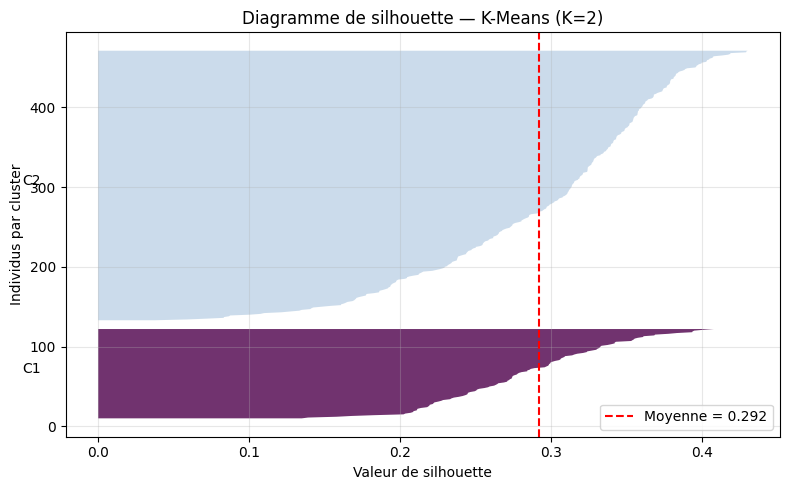

In [22]:
sil_vals = silhouette_samples(X_pca, clusters)

fig, ax = plt.subplots(figsize=(8, 5))
palette = ['#4D004B', '#BFD3E6']
y_lower = 10

for k in range( K_FINAL):
    cluster_sil = np.sort(sil_vals[clusters == k])
    y_upper = y_lower + len(cluster_sil)
    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, cluster_sil,
                     facecolor=palette[k], alpha=0.8)
    ax.text(-0.05, y_lower + len(cluster_sil)/2, 
            f'C{k+1}', fontsize=10)
    y_lower = y_upper + 10

ax.axvline(x=sil, color='red', linestyle='--', 
           label=f'Moyenne = {sil:.3f}')
ax.set_xlabel('Valeur de silhouette')
ax.set_ylabel('Individus par cluster')
ax.set_title(f'Diagramme de silhouette — K-Means (K={K_FINAL})')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

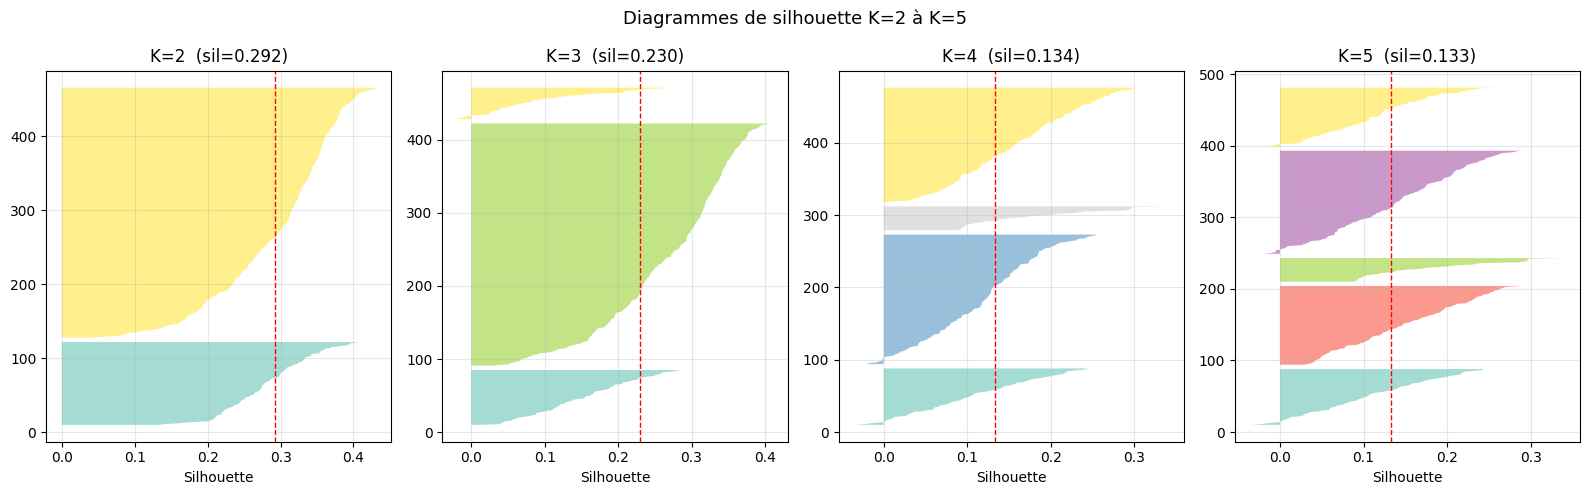

In [24]:
fig, axes = plt.subplots(1, 4, figsize=(16, 5))

for idx, k in enumerate(range(2, 6)):
    km = KMeans(n_clusters=k, init='k-means++',
                n_init='auto', max_iter=100, random_state=42)
    labels = km.fit_predict(X_pca)
    sil_vals_k = silhouette_samples(X_pca, labels)
    avg_sil = silhouette_score(X_pca, labels)
    
    colors = plt.cm.Set3(np.linspace(0, 1, k))
    y_lower = 10
    
    for i in range(k):
        cluster_sil = np.sort(sil_vals_k[labels == i])
        y_upper = y_lower + len(cluster_sil)
        axes[idx].fill_betweenx(np.arange(y_lower, y_upper), 0, cluster_sil,
                                facecolor=colors[i], alpha=0.8)
        y_lower = y_upper + 5
    
    axes[idx].axvline(x=avg_sil, color='red', linestyle='--', linewidth=1)
    axes[idx].set_title(f'K={k}  (sil={avg_sil:.3f})')
    axes[idx].set_xlabel('Silhouette')
    axes[idx].grid(True, alpha=0.3)

plt.suptitle('Diagrammes de silhouette K=2 à K=5', fontsize=13)
plt.tight_layout()
plt.show()

Les diagrammes de silhouette pour K=2 à K=5 confirment que **K=2 et K=3** 
sont les meilleures partitions :

- **K=2** a le score le plus élevé (0.292) mais un des deux clusters 
est peu cohérent, beaucoup de ses individus ont une valeur de silhouette 
proche de 0, ce qui signifie qu'ils sont à la frontière entre les deux groupes.

- **K=3** présente un score légèrement inférieur (0.230) mais une partition 
plus équilibrée, le grand cluster est bien formé et la majorité de ses 
individus dépassent la moyenne.

- **K=4 et K=5** voient leur score chuter brutalement (0.134 et 0.133), 
avec plusieurs clusters dont les individus ont des valeurs négatives ou 
proches de zéro, signe que ces partitions ne sont pas pertinentes.

Nous retenons **K=3** pour la suite de l'analyse.

## Clustering Agglomerative et Hierarchique 

# Gaussian Mixture Models (GMM)

## Choix du nombre de composantes avec le critère BIC

On utilise le critère d'information bayésien (BIC) afin de déterminer le nombre optimal de composantes du modèle GMM.

Le BIC permet de trouver un compromis entre :
- la qualité d'ajustement du modèle (vraisemblance)
- la complexité du modèle (nombre de paramètres)

Le nombre optimal de clusters correspond au minimum du BIC.

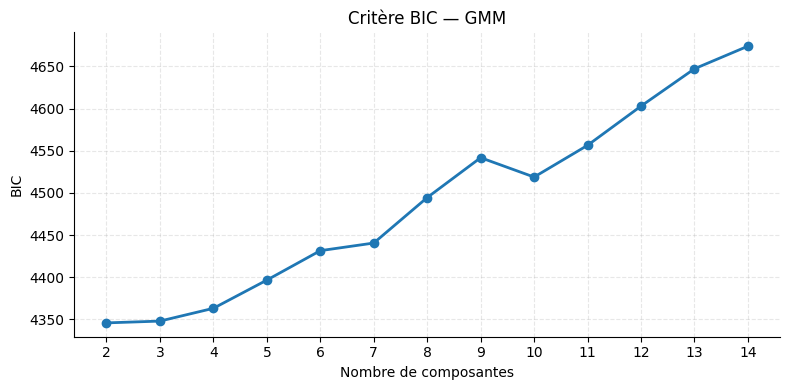

In [25]:
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score

k_max = 15

bic = np.array([
    GaussianMixture(n_components=k, init_params="kmeans", n_init=3, random_state=0)
    .fit(projected).bic(projected)
    for k in range(2, k_max)
])

# --- #

fig, ax = plt.subplots(figsize=(8, 4))

ax.plot(range(2, k_max), bic, marker="o",
        linewidth=2, markersize=6)
ax.set_xlabel("Nombre de composantes")
ax.set_ylabel("BIC")
ax.set_title("Critère BIC — GMM")
ax.set_xticks(range(2, k_max))
ax.spines[["top", "right"]].set_visible(False)
ax.grid(True, linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()



Le critère BIC atteint son minimum pour K = 3.

Cela signifie que le modèle avec 3 composantes offre le meilleur compromis entre :
- la qualité d’ajustement du modèle
- la complexité du modèle

Au-delà de K = 3, le BIC augmente, ce qui indique que l’ajout de composantes supplémentaires entraîne un sur-ajustement, pénalisé par le critère.

Ainsi, on retient K = 3 comme nombre optimal de clusters pour le modèle GMM.

## Application du modèle GMM

On applique le modèle de mélange gaussien avec le nombre de composantes sélectionné à partir du BIC.

Contrairement à K-means, le GMM permet une approche probabiliste du clustering, ce qui permet de mieux capturer des structures de données complexes.

In [29]:
K = 3  # choisi à partir du BIC

gmm = GaussianMixture(n_components=K, n_init=3, random_state=0)
clusters_gmm = gmm.fit_predict(projected)


### Visualisation des clusters dans le plan factoriel

On représente les individus dans le plan factoriel issu de l’ACP, en les coloriant selon leur cluster GMM.

Cela permet de visualiser la structure des groupes identifiés.

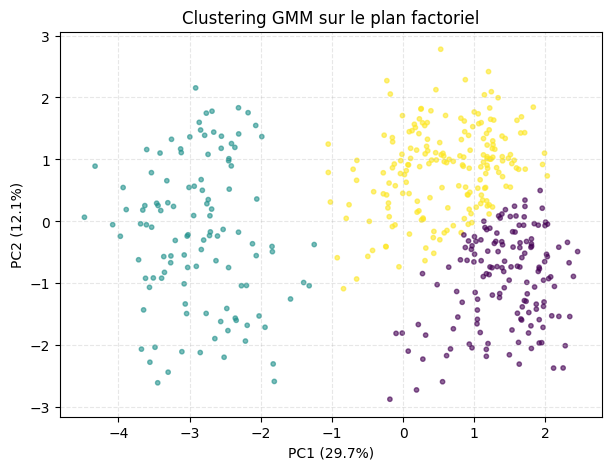

In [40]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.mixture import GaussianMixture

# --- 1. Préparation des données ---

X = df[quant_cols].dropna()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# --- 2. PCA ---

pca = PCA(n_components=2)
projected = pca.fit_transform(X_scaled)

# --- 3. GMM ---

K = 3

gmm = GaussianMixture(n_components=K, n_init=3, random_state=0)
clusters_gmm = gmm.fit_predict(projected)

# --- 4. Visualisation ---

plt.figure(figsize=(7,5))

plt.scatter(projected[:, 0], projected[:, 1],
            c=clusters_gmm, s=10, alpha=0.6)

plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
plt.title("Clustering GMM sur le plan factoriel")

plt.grid(True, linestyle="--", alpha=0.3)
plt.show()

### Interprétation des résultats du GMM

Le modèle GMM avec K = 3 met en évidence trois groupes distincts dans les données.

Sur le plan factoriel (ACP), on observe que :
- les trois clusters sont globalement bien séparés
- un groupe est clairement isolé sur la gauche (valeurs faibles de PC1)
- deux groupes sont situés à droite, avec une séparation selon PC2

Cela indique que la première composante principale (PC1) joue un rôle majeur dans la structuration des données, tandis que la seconde composante (PC2) permet de distinguer des sous-groupes supplémentaires.

La forme des clusters suggère qu’ils ne sont pas parfaitement sphériques, ce qui justifie l’utilisation du modèle GMM plutôt que K-means.

Enfin, la présence de zones de transition entre certains groupes reflète le caractère probabiliste du GMM, où chaque individu peut appartenir partiellement à plusieurs clusters.

### Évaluation du clustering avec le score de silhouette

Le score de silhouette permet d’évaluer la qualité du clustering en mesurant :
- la cohésion des clusters (proximité des points d’un même cluster)
- la séparation entre clusters

Un score élevé indique un bon clustering.

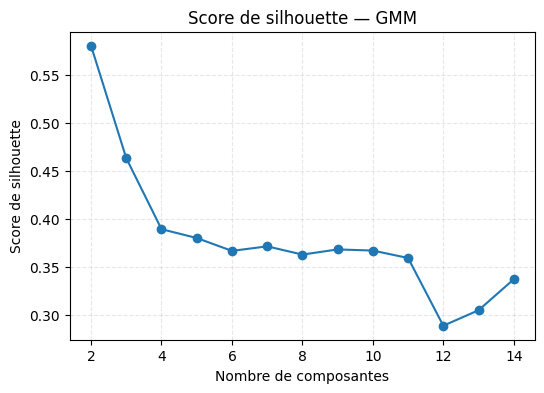

In [41]:
k_max = 15

silhouette = []
for k in range(2, k_max):
    gmm = GaussianMixture(n_components=k, init_params='kmeans',
                          n_init=3, random_state=0)
    clusters_gmm = gmm.fit_predict(projected)
    silhouette.append(
        silhouette_score(projected, clusters_gmm, metric='euclidean')
    )

silhouette = np.array(silhouette)

plt.figure(figsize=(6,4))
plt.plot(range(2, k_max), silhouette, marker='o')

plt.xlabel("Nombre de composantes")
plt.ylabel("Score de silhouette")
plt.title("Score de silhouette — GMM")

plt.grid(True, linestyle="--", alpha=0.3)
plt.show()

### Interprétation du score de silhouette

Le score de silhouette est maximal pour K = 2, ce qui indique que la structure des données est particulièrement bien séparée en deux groupes.

Cependant, le critère BIC suggère K = 3 comme nombre optimal de clusters.

Cela traduit un compromis classique :
- le score de silhouette privilégie des clusters bien séparés
- le BIC prend en compte la structure probabiliste et la complexité du modèle

Dans notre cas, le choix K = 3 permet une description plus fine des données, en identifiant un sous-groupe supplémentaire, au prix d’une légère diminution de la séparation globale.

### Comparaison avec K-means

Le modèle GMM et l’algorithme K-means donnent des résultats globalement cohérents, mais présentent des différences importantes.

K-means :
- suppose des clusters sphériques
- attribue chaque point à un seul cluster

GMM :
- permet des clusters elliptiques
- repose sur une approche probabiliste

Dans notre cas :
- GMM permet de mieux capturer la structure des données
- il identifie des groupes plus flexibles et plus réalistes

Ainsi, le GMM apparaît comme une méthode plus adaptée lorsque les données présentent des formes complexes ou des recouvrements entre clusters.